In [89]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [88]:
df = pd.read_csv(r'C:\Users\Padka\OneDrive\Desktop\Learning Python\world_population.csv')
df.head()

,Rank,CCA3,Country,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
0,36,AFG,Afghanistan,Kabul,Asia,41128771.0,38972230.0,33753499.0,28189672.0,19542982.0,10694796.0,12486631.0,10752971.0,652230.0,63.0587,1.0257,0.52
1,138,ALB,Albania,Tirana,Europe,2842321.0,2866849.0,2882481.0,2913399.0,3182021.0,3295066.0,2941651.0,2324731.0,28748.0,98.8702,0.9957,0.04
2,34,DZA,Algeria,Algiers,Africa,44903225.0,43451666.0,39543154.0,35856344.0,30774621.0,25518074.0,18739378.0,13795915.0,2381741.0,18.8531,1.0164,0.56
3,213,ASM,American Samoa,Pago Pago,Oceania,44273.0,46189.0,51368.0,54849.0,58230.0,47818.0,32886.0,27075.0,199.0,222.4774,0.9831,0.00
4,203,AND,Andorra,Andorra la Vella,Europe,79824.0,77700.0,71746.0,71519.0,66097.0,53569.0,35611.0,19860.0,468.0,170.5641,1.0100,0.00


In [114]:
pd.set_option('display.float_format',lambda x: '%.2f' % x) #set display number .2floating num

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
df.isnull().sum()

In [ ]:
df.nunique() #count distinct

C:\Users\Padka\AppData\Local\Temp\ipykernel_49764\2276067912.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='2022 Population', y='Country', data=top_10, palette='viridis')


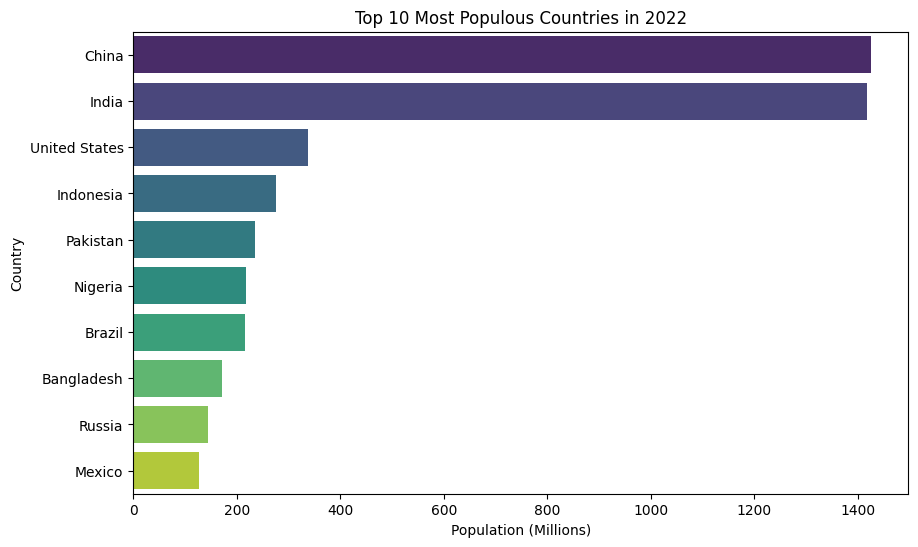

In [109]:
top_10 = df.sort_values(by="2022 Population", ascending=False).head(10)
top_10['2022 Population'] = top_10['2022 Population'] / 10**6
plt.figure(figsize=(10, 6))
sns.barplot(x='2022 Population', y='Country', data=top_10, palette='viridis')
plt.title('Top 10 Most Populous Countries in 2022')
plt.xlabel('Population (Millions)')
plt.ylabel('Country')
plt.show()

### Key Insights: Top 10 Most Populous Countries
* **Dominant Nations:** The bar chart clearly identifies the world's demographic giants, with certain countries significantly outpacing the rest of the world in terms of sheer population size.
* **Visual Breakdown:** Transforming the sorted data into a horizontal bar plot provides an immediate, high-impact visual comparison of population scale across the top 10 territories.

In [ ]:
df.corr(numeric_only=True)

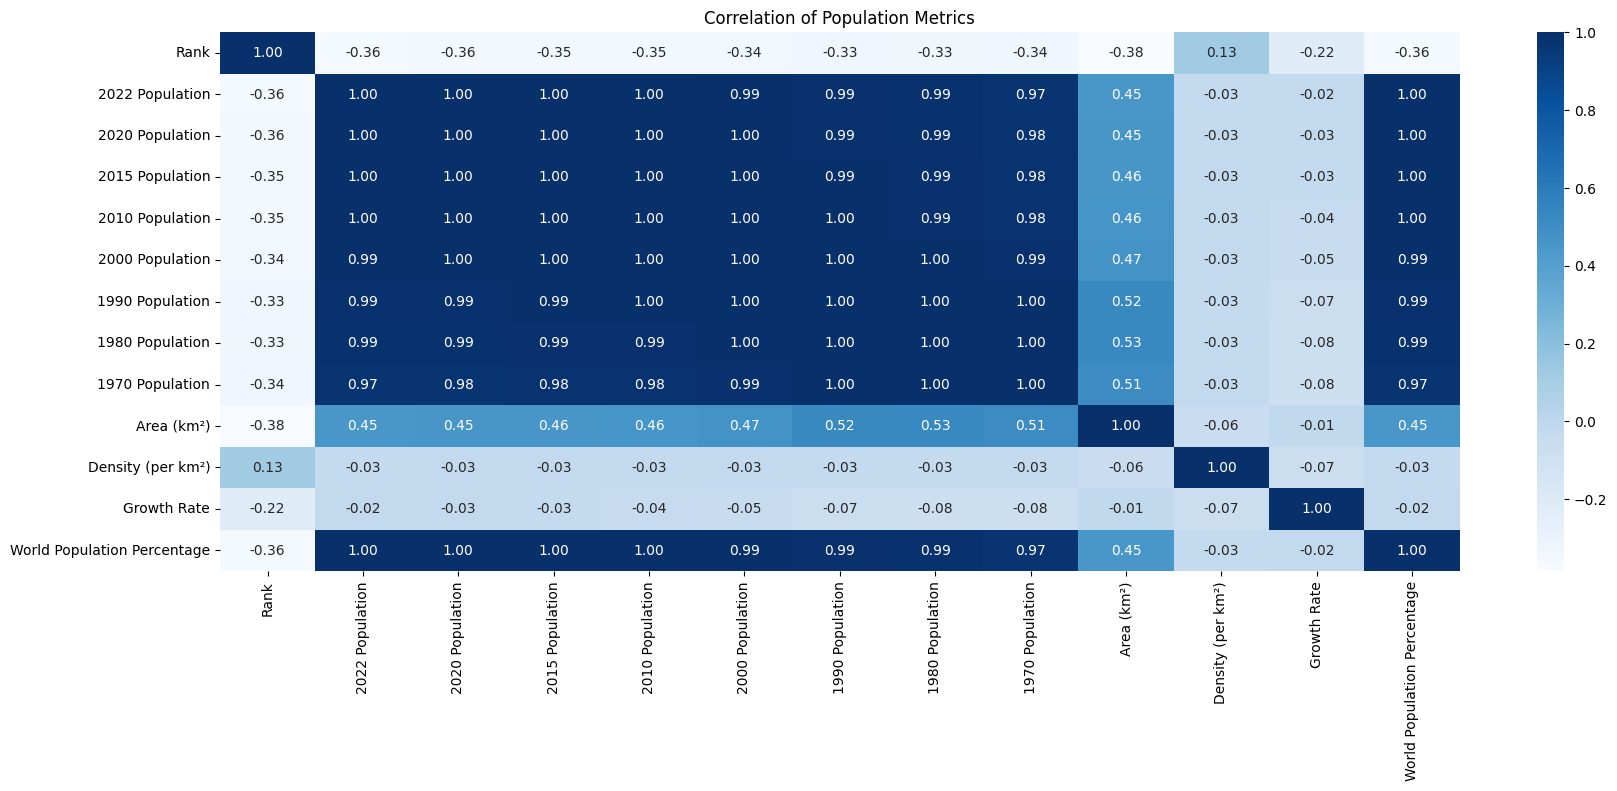

<Figure size 2000x700 with 0 Axes>

In [27]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation of Population Metrics')
plt.figure(figsize=(20,7))
plt.show()

### Key Insights: Correlation Analysis
* **High Inter-temporal Correlation:** There is an extremely strong positive correlation (near 1.00) among population data from 1970 to 2022, indicating consistent and predictable growth patterns globally over the past 50 years.
* **Area vs. Population:** Land area shows a moderate positive correlation with population sizes, confirming that larger countries generally support larger populations, though geographic density varies.

In [ ]:
df.groupby('Continent').mean(numeric_only=True).sort_values(by='2022 Population',ascending=False)

In [ ]:
df[df['Continent'].str.contains('Oceania')]

In [116]:
col = [ '1970 Population',
       '1980 Population', '1990 Population', '2000 Population',
       '2010 Population', '2015 Population', '2020 Population',
       '2022 Population']

In [ ]:
continent = df.groupby('Continent')
continent = continent[col].mean() / 10**6
continent_growth = continent.transpose()
continent_growth.head()

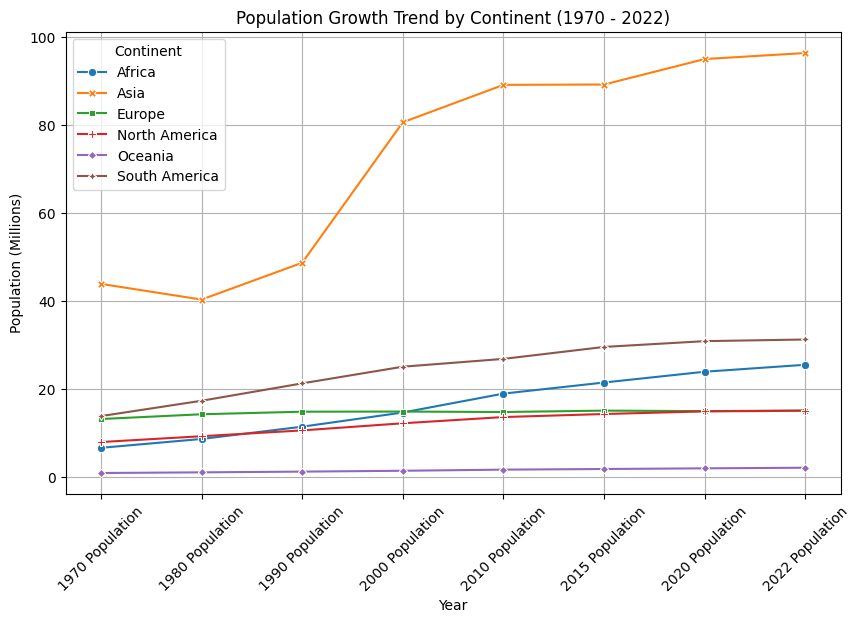

In [119]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=continent_growth, markers=True, dashes=False)
plt.title('Population Growth Trend by Continent (1970 - 2022)')
plt.xlabel('Year')
plt.ylabel('Population (Millions)')                                                                                                            
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Key Insights: Population Growth Trend by Continent
* **Rapid Growth in Asia:** **Asia** demonstrates the most aggressive and steep population growth trajectory from 1970 to 2022 compared to all other continents.
* **Stable Trajectories:** **Europe** exhibits a flattening growth curve in recent decades, showing a demographic transition towards stabilization.
* **Lowest Average:** **Oceania** consistently maintains the lowest and most stable average population throughout the observed 52-year period.

In [ ]:
df.boxplot()
plt.xticks(rotation=45)

In [ ]:
df.select_dtypes(include='object') #find some type

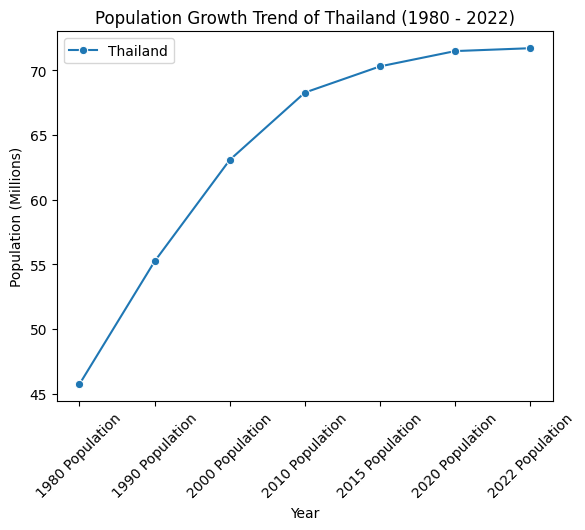

In [59]:
Thailand = df[df['Country'].str.contains('Thailand')]
Thailand = Thailand[col]
Thailand = Thailand.select_dtypes(include=['number']) / 1_000_000
sns.lineplot(data=Thailand.transpose(), markers=True, dashes=False)
plt.title('Population Growth Trend of Thailand (1980 - 2022)')
plt.xlabel('Year')
plt.ylabel('Population (Millions)')
plt.xticks(rotation=45)
plt.legend(['Thailand'])



### Key Insights: Population Growth Trend of Thailand
* **Rapid Initial Growth:** Thailand experienced a steep and continuous population increase from 1980 through the early 2000s, driven by rapid demographic expansion.

* **Transition to Stabilization:** In recent decades (specifically post-2010), the growth curve exhibits a significant flattening, signaling a clear demographic transition towards population stabilization.

* **Peak and Plateau:** By 2022, the population trajectory reaches its historical peak at approximately 70-71 million, shifting into a near-stationary growth phase with minimal year-over-year increases.